In [116]:
library(torch)
library(luz)
#library(lecospectR)

In [117]:
source("./Functions/lecospectR.R", verbose = FALSE, echo = FALSE)

In [118]:
net <- nn_module(
    "resnet14",
     initialize = function(num_components = NUM_VARS, num_levels = 8) {
      self$internal_dimension <- 256

        self$l1 <- nn_conv1d(
          600,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l2 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l3 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l4 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l5 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l6 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l7 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l8 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l9 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l10 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l11 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l12 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l13 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l14 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l15 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l16 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l17 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l18 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l19 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l20 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l21 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l22 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )

        self$l23 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l24 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$l25 <- nn_conv1d(
          self$internal_dimension,
          self$internal_dimension,
          3, 
          padding = 1
          )
        self$linear <- nn_linear(self$internal_dimension, 8)
    
  },

  forward = function(x) {
    x1 <- self$l1(x)
    x2 <- self$l2(x1) + x1
    x3 <- self$l3(x2) + x2
    x4 <- self$l4(x3) + x3
    x5 <- self$l5(x4) + x4
    x6 <- self$l6(x5) + x5
    x7 <- self$l7(x6) + x6
    x8 <- self$l8(x7) + x7
    x9 <- self$l9(x8) + x8
    x10 <- self$l10(x9) + x9
    x11 <- self$l11(x10) + x10
    x12 <- self$l12(x11) + x11
    x13 <- self$l13(x12) + x12
    x14 <- self$l14(x13) + x13
    x15 <- self$l15(x14) + x14
    x16 <- self$l16(x15) + x15
    x17 <- self$l17(x16) + x16
    x18 <- self$l18(x17) + x17
    x19 <- self$l19(x18) + x18
    x20 <- self$l20(x19) + x19
    x21 <- self$l21(x20) + x20
    x22 <- self$l22(x21) + x21
    x23 <- self$l23(x22) + x22
    x24 <- self$l24(x23) + x23
    x25 <- self$l25(x24) + x24

    #class_label <- torch_argmax(x_D, dim = 2)
    #print(paste0("D: ", dim(x_D)))

    return(self$linear(x25$squeeze()))
  }
)

In [119]:
add_channel_dim <- function(img) {
   x <- img$unsqueeze(1)
   return(torch_transpose(x, 1,2))
}

In [120]:
create_variable_names <- function(start, stop){
    names <- c()
    for(i in start:stop){
        names <- append(
            names, 
            paste0("X", i))
    }

    return(names)
}

In [121]:
independent_variables <- create_variable_names(400L, 999L)

dependent_variable <- "FncGrp1" 
NUM_VARS <- length(independent_variables)
print(length(independent_variables))

[1] 600


In [122]:
# define the dataset
data_df <- read.csv(file = "Data/Ground_Validation/PFT_image_spectra/PFT_Image_SpectralLib_Clean.csv")


In [123]:

lecospec_dataset <- torch::dataset(
    name = "lecospec_image",
    initialize = function(df, transform = function(x){x}) {
        self$x <- as.matrix(df[, independent_variables])
        self$y <- torch_tensor(
            as.matrix(
                as.integer(
                    as.factor(
                        df[, dependent_variable]
                        )
                    )
                )
            )
        self$transform <- transform
    },

    .getitem = function(i) {
        list(
            x = self$transform(torch_flatten(self$x[i,])),
            y = torch_flatten(self$y[i])$squeeze()
        )
    },

    .length = function() {
        self$y$size()[[1]]
    }
)

In [124]:
head(data_df)

,X,UID,ScanNum,sample_name,PFT,FncGrp1,Site,X398,X399,X400,⋯,X990,X991,X992,X993,X994,X995,X996,X997,X998,X999
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,BisonGulchPFTsBetula1,1,spec_1,Betula,ShrubDecid,BisonGulch,0.05814769,0.05926529,0.06028869,⋯,0.6815182,0.6811660,0.6890470,0.7040298,0.7249807,0.7507566,0.7801884,0.8121027,0.8453261,0.8786852
2,2,BisonGulchPFTsBetula1,1,spec_2,Betula,ShrubDecid,BisonGulch,0.04456014,0.04778814,0.05079318,⋯,0.6706666,0.6683159,0.6786394,0.7000307,0.7308801,0.7695067,0.8140391,0.8625739,0.9132079,0.9640378
3,3,BisonGulchPFTsBetula1,1,spec_3,Betula,ShrubDecid,BisonGulch,0.03929324,0.04265593,0.04557066,⋯,0.5152525,0.5091915,0.5178217,0.5395294,0.5726982,0.6156166,0.6663192,0.7227978,0.7830447,0.8450520
4,4,BisonGulchPFTsBetula1,1,spec_4,Betula,ShrubDecid,BisonGulch,0.13230228,0.11122692,0.09129034,⋯,0.5120581,0.5113880,0.5348292,0.5745538,0.6227243,0.6723311,0.7185860,0.7570701,0.7833644,0.7930498
5,5,BisonGulchPFTsBetula1,1,spec_5,Betula,ShrubDecid,BisonGulch,0.05211388,0.05565497,0.05878525,⋯,0.6863419,0.6680365,0.6509006,0.6344450,0.6181806,0.6017555,0.5851848,0.5685449,0.5519121,0.5353626
6,6,BisonGulchPFTsBetula1,1,spec_6,Betula,ShrubDecid,BisonGulch,0.06955397,0.06788242,0.06631141,⋯,0.7354495,0.7371508,0.7445194,0.7567953,0.7732173,0.7930235,0.8154512,0.8397375,0.8651196,0.8908347


In [125]:
num_per_pft <- 300
train_test_data <- create_patch_balanced_sample(
    data_df,
    test_count = 20,
    train_count = NULL,
    verbose = FALSE
    )

split_2_train <- create_patch_balanced_sample(
    train_test_data$remainder,
    test_count = num_per_pft,
    train_count = 1000,
    verbose = FALSE
    )

In [126]:
print(names(split_2_train))

[1] "selection"         "remainder"         "samples_per_patch"
[4] "samples_per_class"


In [127]:
print(split_2_train$selection)

      X                   UID ScanNum sample_name    PFT        FncGrp1
24   24 BisonGulchPFTsBetula1       1     spec_24 Betula     ShrubDecid
2     2 BisonGulchPFTsBetula1       1      spec_2 Betula     ShrubDecid
17   17 BisonGulchPFTsBetula1       1     spec_17 Betula     ShrubDecid
19   19 BisonGulchPFTsBetula1       1     spec_19 Betula     ShrubDecid
16   16 BisonGulchPFTsBetula1       1     spec_16 Betula     ShrubDecid
9     9 BisonGulchPFTsBetula1       1      spec_9 Betula     ShrubDecid
25   25 BisonGulchPFTsBetula1       1     spec_25 Betula     ShrubDecid
21   21 BisonGulchPFTsBetula1       1     spec_21 Betula     ShrubDecid
6     6 BisonGulchPFTsBetula1       1      spec_6 Betula     ShrubDecid
14   14 BisonGulchPFTsBetula1       1     spec_14 Betula     ShrubDecid
1     1 BisonGulchPFTsBetula1       1      spec_1 Betula     ShrubDecid
23   23 BisonGulchPFTsBetula1       1     spec_23 Betula     ShrubDecid
60   60 BisonGulchPFTsBetula2       2     spec_35 Betula     Shr

In [128]:
train_indices <- sample(1:nrow(data_df), 250)
train_ds <- lecospec_dataset(
    split_2_train$selection,
    transform = add_channel_dim
    )
valid_ds <- lecospec_dataset(
    train_test_data$selection, 
    transform = add_channel_dim
    )

length(train_ds)
length(valid_ds)

[1] 2222

[1] 160

In [129]:
# create a dataloader
test_dl <- torch::dataloader(
    valid_ds,
    batch_size = 80,
    shuffle = FALSE
)

train_dl <- torch::dataloader(
    train_ds,
    batch_size = 240,
    shuffle = TRUE
)

In [130]:
batch <- dataloader_make_iter(train_dl) %>% dataloader_next()
print(dim(batch$x))
print(dim(batch$y))

[1] 240 600   1
[1] 240


In [131]:
print(batch$x$shape)

[1] 240 600   1


In [132]:
print(batch$y$shape)

[1] 240


In [133]:
model <- net()
model(batch$x)


torch_tensor
-0.0108  0.0377 -0.0437 -0.0313  0.1088  0.2127 -0.0459  0.1487
-0.0443  0.0436 -0.0256 -0.0384  0.1459  0.2456 -0.0452  0.1533
-0.0852  0.0358 -0.0713 -0.0245  0.1421  0.2667 -0.0352  0.1721
 0.0056  0.0569 -0.0227 -0.0497  0.1284  0.2263 -0.0508  0.1217
 0.0432  0.0604  0.0017 -0.0465  0.1126  0.1855 -0.0603  0.1035
-0.0256  0.0552 -0.0300 -0.0420  0.1375  0.2411 -0.0483  0.1304
 0.0027  0.0504 -0.0419 -0.0385  0.1132  0.2130 -0.0474  0.1274
 0.0066  0.0498 -0.0092 -0.0406  0.1232  0.2026 -0.0593  0.1223
 0.0090  0.0584 -0.0088 -0.0484  0.1244  0.2169 -0.0533  0.1205
-0.1024  0.0397 -0.0727 -0.0253  0.1633  0.2862 -0.0299  0.1807
-0.0994  0.0340 -0.0550 -0.0324  0.1679  0.2868 -0.0337  0.1831
 0.0019  0.0420 -0.0358 -0.0343  0.1128  0.2065 -0.0518  0.1357
-0.0684  0.0404 -0.0255 -0.0306  0.1473  0.2524 -0.0458  0.1614
-0.0034  0.0478 -0.0352 -0.0420  0.1169  0.2208 -0.0469  0.1360
-0.0540  0.0389 -0.0503 -0.0346  0.1380  0.2473 -0.0353  0.1668
 0.0237  0.0669 -0.0158 -0.

In [134]:
batch$y

torch_tensor
 8
 7
 7
 2
 1
 5
 4
 1
 8
 5
 5
 1
 8
 1
 7
 2
 8
 6
 5
 7
 4
 6
 5
 8
 3
 3
 5
 7
 3
 7
... [the output was truncated (use n=-1 to disable)]
[ CPULongType{240} ]

In [135]:
net_fitted <- net %>%
  setup(
    loss = nn_cross_entropy_loss(),
    optimizer = optim_adam
  ) %>%
  set_opt_hparams(lr = 0.001) %>%
  fit(
    train_dl,
    epochs = 2000,
    valid_data = test_dl
  )

In [136]:
net_fitted

A `luz_module_fitted`
── Time ────────────────────────────────────────────────────────────────────────
• Total time: 13m 43.9s
• Avg time per training epoch: 1.6s

── Results ─────────────────────────────────────────────────────────────────────
Metrics observed in the last epoch.

ℹ Training:
loss: 0.7534

── Model ───────────────────────────────────────────────────────────────────────
An `nn_module` containing 3,022,344 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• l1: <nn_conv1d> #461,056 parameters
• l2: <nn_conv1d> #196,864 parameters
• l3: <nn_conv1d> #196,864 parameters
• l4: <nn_conv1d> #196,864 parameters
• l5: <nn_conv1d> #196,864 parameters
• l6: <nn_conv1d> #196,864 parameters
• l7: <nn_conv1d> #196,864 parameters
• l8: <nn_conv1d> #196,864 parameters
• l9: <nn_conv1d> #196,864 parameters
• l10: <nn_conv1d> #196,864 parameters
• l11: <nn_conv1d> #196,864 parameters
• l12: <nn_conv1d> #196,864 parameters
• l13: <nn_conv1d> #19

In [137]:
predict(net_fitted,newdata = batch$x)

torch_tensor
 -0.5894  -0.5438   0.7038   0.4459  -1.0079   0.8796  -0.2242   0.2675
 -4.9368   0.2732  -2.7358 -13.6403   5.4341   0.7866   5.3211   4.4205
 -7.3505   2.7294  -3.1227 -10.5375   6.2263  -1.0580   7.1393   2.7484
 -1.3391   2.5575  -2.2231  -1.6535   2.1347   0.1798   0.2610   0.2544
  5.8696  -3.7882   2.9104   1.7965  -5.4784   3.1398  -5.9181   0.7708
 -3.0274   3.1724  -2.8394  -3.6992   3.7391  -0.0974   2.0437   0.4610
  2.3649   1.2466   1.3059  11.3414  -2.9362   0.6792  -4.6877  -4.1483
  6.6893  -4.1663   5.0188   7.3842  -7.2187   2.9261  -7.6450  -1.3681
 -0.5696   1.7880  -1.9268  -5.6366   1.0308   0.3989   0.5632   2.1783
-10.4238   2.8876  -6.3220 -13.1417  11.3278  -0.8958   9.4787   3.5596
-11.3682   2.8619  -6.8708 -14.7989  13.0256   0.0766  10.3273   3.2947
  2.6959  -4.4355   3.0965  -1.5410  -3.6861   2.7192  -2.5553   1.6840
 -5.3370   0.7345  -5.1057 -16.2177   4.9135  -0.3545   6.3408   7.5144
 -0.8740   2.6202  -0.6857   1.3202  -0.0812  -0.48

## Next

Need to define the correct nueral net architecture, and then the training loop should work as intended.  This is likely some kind of U-Net from a paper.  

Just a matter of finding the correct one and plugging the layers into the model above.  

Hopefully that works directly

In [138]:
preds <- predict(net_fitted, test_dl)

torch_tensor
 -6.1478  -1.6366  -0.6251  -4.6981   6.4175   0.9133   3.6587   1.1988
 -8.5577   1.1496  -5.0676 -15.6468   9.7283   1.1903   8.7818   3.8318
  1.4112  -6.6299   3.5625  -7.3497  -2.5081   4.4576  -0.1730   2.9918
 -0.3672  -4.2505  -0.2774  -7.5085   1.7228   3.7994   0.4871   3.0313
  1.4661  -2.3497   0.6643  -4.0912  -1.8882   2.4640  -0.9032   2.1583
  0.5556  -0.4141  -1.2453  -2.4349  -0.5989   2.5109   0.1651   0.6150
  2.9099  -4.2651   1.7786  -3.9251  -2.8725   3.2864  -2.5186   2.6779
  1.5242  -4.1488   2.1113  -2.9978  -0.7397   3.7838  -1.6414   0.7623
  3.5165  -6.2272   1.5274  -2.5045  -2.6267   5.2401  -2.9551   1.9014
  3.6968  -6.2172   1.4638  -4.2338  -2.6570   5.4819  -2.8571   2.4704
 -0.4781  -3.8736   0.2203  -4.6492   1.0348   3.6631   0.5179   1.6043
  0.4776  -3.1071   1.2716  -2.4073  -0.3596   3.8492  -0.2518  -0.0673
  4.9649  -5.1495   3.2125  -0.2837  -5.3373   3.6685  -4.6463   1.7124
  4.6400  -5.5765   1.3221  -1.0524  -4.3178   4.09

List of 138
 $ line                            :List of 6
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ lineend      : chr "butt"
  ..$ arrow        : logi FALSE
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_line" "element"
 $ rect                            :List of 5
  ..$ fill         : chr "white"
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_rect" "element"
 $ text                            :List of 11
  ..$ family       : chr ""
  ..$ face         : chr "plain"
  ..$ colour       : chr "black"
  ..$ size         : num 11
  ..$ hjust        : num 0.5
  ..$ vjust        : num 0.5
  ..$ angle        : num 0
  ..$ lineheight   : num 0.9
  ..$ margin       : 'margin' num [1:4] 0points 0points 0points 0points
  .. ..- attr(*, "unit")= int 8
  ..$ debug        : logi FALSE
  ..$ inherit.blank: l

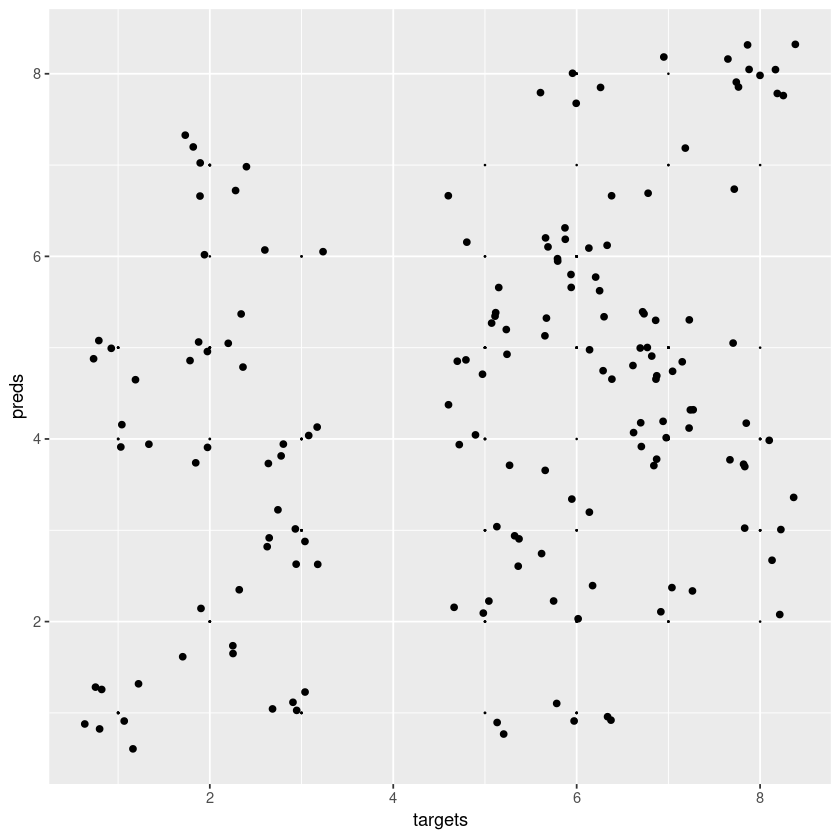

In [139]:
#test_dl <- dataloader(valid_ds, batch_size = 5000)
targets <- (test_dl %>% dataloader_make_iter() %>% dataloader_next())$y %>% as.numeric()

y_pred <- torch_argmax(preds, dim = 2) %>% as.numeric()
df <- data.frame(preds = y_pred, targets = targets)
#library(ggplot2)

print(preds)


ggplot(df, aes(x = targets, y = preds)) +
  geom_point(size = 0.1) +
  geom_jitter()
  theme_classic() +
  xlab("true correlations") +
  ylab("model predictions")

#plot(y_pred, targets)


In [140]:
df$preds %>% as.factor() %>% levels()

[1] "1" "2" "3" "4" "5" "6" "7" "8"

In [141]:
df$targets %>% as.factor() %>% levels()

[1] "1" "2" "3" "5" "6" "7" "8"

In [142]:
target_f <- df$targets %>% as.factor()
levels(target_f) <- c(levels(target_f), '4')

In [143]:
conf <- caret::confusionMatrix(
    df$preds %>% as.factor(),
    target_f
)

write(rjson::toJSON(conf), file = "./resnet_confusion_matrix.json")

Warning message in confusionMatrix.default(df$preds %>% as.factor(), target_f):
“Levels are not in the same order for reference and data. Refactoring data to match.”


Confusion Matrix and Statistics

          Reference
Prediction  1  2  3  5  6  7  8  4
         1  7  0  4  2  4  0  0  0
         2  0  5  0  3  3  3  1  0
         3  0  0  7  4  3  0  4  0
         5  4  6  0  8  6 12  1  0
         6  0  1  2  2 12  0  0  0
         7  0  6  0  1  1  2  1  0
         8  0  0  0  0  4  1 10  0
         4  3  2  5  4  1 10  5  0

Overall Statistics
                                         
               Accuracy : 0.3188         
                 95% CI : (0.2474, 0.397)
    No Information Rate : 0.2125         
    P-Value [Acc > NIR] : 0.001135       
                                         
                  Kappa : 0.2295         
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 5 Class: 6 Class: 7
Sensitivity           0.50000  0.25000  0.38889   0.3333   0.3529  0.07143
Specificity           0.93151  0.92857  0.92254   0.7868   0.

In [144]:
luz_save(obj = net_fitted,path = "./dl_resnet_v0.dat")